# EMT IEEE 9-bus inverter state-space validation

This notebook validates state-space extraction on a modified IEEE 9-bus network containing an infinite-bus Thevenin equivalent, a 200 MVA grid-forming inverter at BUS2, and a 100 MVA grid-following inverter at BUS3. The study uses physical transformer magnetizing branches and power-flow-consistent EMT initialization.

The current scope has two results: (1) a balanced-network modal baseline with quantitative initialization checks, and (2) a scenario-driven PLL interaction for which the intact network is stable but the `LINE96` post-contingency equilibrium is unstable. A small temporary BUS3 load pulse excites the same mode in EMT simulation.


In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.linalg import eigvals, svd
from scipy.signal import butter, sosfiltfilt, hilbert

candidates = [Path.cwd(), *Path.cwd().parents]
repo_root = next((p for p in candidates if (p/'dpsim').is_dir() and (p/'dpsim-models').is_dir()), None)
if repo_root is None:
    raise FileNotFoundError('Run this notebook from within the DPSim source tree.')
log_root = repo_root/'logs'
runs = {
    'baseline': 'ieee9_200mva_baseline',
    'intact, low PLL damping': 'ieee9_pll_bus3_intact',
    'LINE96 out, low PLL damping': 'ieee9_pll_bus3_line96',
    'settled dynamic LINE96 outage': 'ieee9_dynamic_line96_settled70',
}
for label, run in runs.items():
    if not (log_root/run).exists():
        raise FileNotFoundError(f'Missing {log_root/run}; reproduce the C++ run listed below.')

def modal_data(run, label='baseline'):
    root = log_root/run/'modal'/label
    return pd.read_csv(root/'modes.csv'), pd.read_csv(root/'participation.csv'), pd.read_csv(root/'summary.csv')

def pll_mode(run, label='baseline'):
    modes, participation, _ = modal_data(run, label)
    candidates = modes[np.isfinite(modes.lambda_real) & (modes.lambda_imag > 0)].copy()
    pll = participation[participation.state_name.str.contains('GEN3.theta_pll', regex=False)]
    scores = pll.groupby('mode').p_abs.max()
    candidates['pll_score'] = candidates['mode'].map(scores).fillna(0.0)
    return candidates.loc[candidates.pll_score.idxmax()]

executable = repo_root/'build/dpsim/examples/cxx/EMT_Ph3_IEEE9_Inverter_StateSpaceValidation'
print('Executable:', executable)


Executable: /home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/EMT_Ph3_IEEE9_Inverter_StateSpaceValidation


## Reproduction commands

The two converter controls are identical between the intact and post-contingency cases. Only `outaged_line` changes. The low-damping setting changes (K_{p,\mathrm{PLL}}) alone; (K_i) remains fixed.


In [16]:
commands = [
    f'{executable} -n ieee9_200mva_baseline -t 5e-5 -d 0.5 -l WARN -o log=true',
    f'{executable} -n ieee9_pll_bus3_intact -t 5e-5 -d 3.0 -l WARN -o log=true -o gfl_kppll=0.001 -o scenario=load_pulse -o event_time_s=0.1 -o pulse_duration_s=0.02 -o load_step_p_pu=0.005 -o disturbance_bus=BUS3',
    f'{executable} -n ieee9_pll_bus3_line96 -t 5e-5 -d 3.0 -l WARN -o log=true -o gfl_kppll=0.001 -o outaged_line=LINE96 -o scenario=load_pulse -o event_time_s=0.1 -o pulse_duration_s=0.02 -o load_step_p_pu=0.005 -o disturbance_bus=BUS3',
]
formulation_steps_us = [10, 25, 50, 75, 100]
commands += [
    f'{executable} -n ieee9_form_{formulation}_{dt_us}us -t {dt_us}e-6 -d 0.1 -l WARN -o log=false -o gfl_formulation={formulation}'
    for formulation in ['variable', 'split'] for dt_us in formulation_steps_us
]
commands += [
    f'{executable} -n ieee9_form_td_split_50us -t 50e-6 -d 0.5 -l WARN -o log=true -o gfl_formulation=split -o scenario=load_pulse -o event_time_s=0.0 -o pulse_duration_s=0.002 -o load_step_p_pu=0.002 -o disturbance_bus=BUS3',
    f'{executable} -n ieee9_form_td_split_100us -t 100e-6 -d 0.5 -l WARN -o log=true -o gfl_formulation=split -o scenario=load_pulse -o event_time_s=0.0 -o pulse_duration_s=0.002 -o load_step_p_pu=0.002 -o disturbance_bus=BUS3',
    f'{executable} -n ieee9_form_td_variable_100us -t 100e-6 -d 0.5 -l WARN -o log=true -o gfl_formulation=variable -o scenario=load_pulse -o event_time_s=0.0 -o pulse_duration_s=0.002 -o load_step_p_pu=0.002 -o disturbance_bus=BUS3',
    f'{executable} -n ieee9_dynamic_line96_settled70 -t 50e-6 -d 70.0 -l WARN -o log=true -o compact_log=true -o gfl_formulation=variable -o gfl_kppll=0.003 -o line96_breaker=true -o scenario=line_outage -o event_time_s=0.5',
]
print('\n'.join(commands))


/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/EMT_Ph3_IEEE9_Inverter_StateSpaceValidation -n ieee9_200mva_baseline -t 5e-5 -d 0.5 -l WARN -o log=true
/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/EMT_Ph3_IEEE9_Inverter_StateSpaceValidation -n ieee9_pll_bus3_intact -t 5e-5 -d 3.0 -l WARN -o log=true -o gfl_kppll=0.001 -o scenario=load_pulse -o event_time_s=0.1 -o pulse_duration_s=0.02 -o load_step_p_pu=0.005 -o disturbance_bus=BUS3
/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/EMT_Ph3_IEEE9_Inverter_StateSpaceValidation -n ieee9_pll_bus3_line96 -t 5e-5 -d 3.0 -l WARN -o log=true -o gfl_kppll=0.001 -o outaged_line=LINE96 -o scenario=load_pulse -o event_time_s=0.1 -o pulse_duration_s=0.02 -o load_step_p_pu=0.005 -o disturbance_bus=BUS3
/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/EMT_Ph3_IEEE9_Inverter_StateSpaceValidation -n ieee9_form_variable_10us -t 10e-6 -d 0.1 -l WARN -o log=false -o gfl_formulation=variabl

## Steady-state time-domain verification

Before interpreting eigenvalues, the undisturbed baseline is simulated for 0.5 s from the power-flow initialization. A 0.15 s initialization-settling interval is omitted and the displayed time is reset to zero; no event is applied. The traces are deviations from their final-cycle means and therefore show explicitly that the presented observation window starts in steady state. The complete-run displacement and final-cycle span are retained quantitatively in Study 1 below.


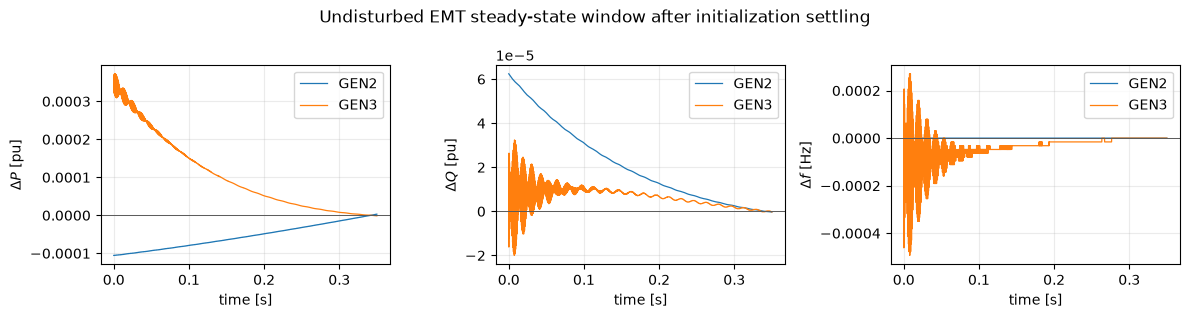

In [17]:
baseline_log = pd.read_csv(log_root/runs['baseline']/f"{runs['baseline']}.csv", skipinitialspace=True)
baseline_log.columns = baseline_log.columns.str.strip()
baseline_log = baseline_log[baseline_log.time > 0].sort_values('time').reset_index(drop=True)
time = baseline_log.time.to_numpy()
final_cycle = time >= time[-1] - 1/60
steady_window = time >= 0.15
shown_time = time[steady_window] - time[steady_window][0]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
converter_data = [('GEN2', 200e6, 'tab:blue'), ('GEN3', 100e6, 'tab:orange')]
for converter, rating, color in converter_data:
    p_pu = baseline_log[f'{converter}.p_inst'].to_numpy()/rating
    q_pu = baseline_log[f'{converter}.q_inst'].to_numpy()/rating
    omega_name = 'GEN2.omega' if converter == 'GEN2' else 'GEN3.omega_pll'
    frequency = baseline_log[omega_name].to_numpy()/(2*np.pi)
    axes[0].plot(shown_time, (p_pu-p_pu[final_cycle].mean())[steady_window], color=color, lw=0.9, label=converter)
    axes[1].plot(shown_time, (q_pu-q_pu[final_cycle].mean())[steady_window], color=color, lw=0.9, label=converter)
    axes[2].plot(shown_time, (frequency-frequency[final_cycle].mean())[steady_window], color=color, lw=0.9, label=converter)
for ax, ylabel in zip(axes, [r'$\Delta P$ [pu]', r'$\Delta Q$ [pu]', r'$\Delta f$ [Hz]']):
    ax.axhline(0, color='0.35', lw=0.7)
    ax.set_xlabel('time [s]'); ax.set_ylabel(ylabel); ax.grid(alpha=0.25); ax.legend()
fig.suptitle('Undisturbed EMT steady-state window after initialization settling')
fig.tight_layout()


## Study 1 — balanced modal baseline and initialization

**Purpose.** Establish that the EMT network starts sufficiently close to its power-flow operating point and that the modal reduction removes only decoupled zero-sequence coordinates. The residual is an explicit guard: the reduction fails if zero-sequence states are coupled to the retained subsystem.

The ideal linear magnetizing inductors also produce nearly neutral 60 Hz flux-offset modes. They are retained in the CSV output but are not interpreted as converter stability modes. Near-Nyquist trapezoidal line-memory modes are likewise retained for traceability and omitted from the physical-mode view.


,signal,initial_to_final_pu,final_period_span_pu
0,GEN2.p,-1.880000e-05,1.200000e-05
1,GEN2.q,-7.263000e-04,1.600000e-06
2,GEN2.omega,0.000000e+00,0.000000e+00
3,GEN3.p,3.330000e-05,2.400000e-06
4,GEN3.q,-1.550000e-05,7.000000e-07
5,GEN3.omega,5.000000e-07,1.000000e-07


,state_count,auxiliary_reduction_residual,auxiliary_reduction_pole_error,zero_sequence_coupling_residual
0,81,1.494751e-17,1.902133e-10,3.952830e-14


,mode,lambda_real,frequency_hz
77,77,-0.1402,0.0737
59,59,-1.2081,60.0019
57,57,-1.4329,60.0021
74,74,-3.1061,0.2324
55,55,-3.7408,60.0315
71,71,-20.0281,0.0088
6,6,-37.4002,1817.8413
8,8,-39.8024,1722.8634
53,53,-65.9570,60.0382
66,66,-100.1362,0.2236


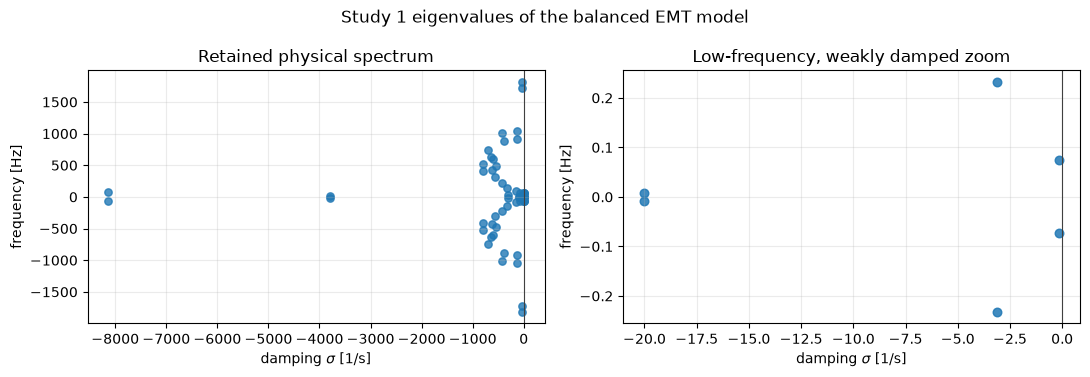

In [18]:
baseline = runs['baseline']
op = pd.read_csv(log_root/baseline/'operating_point.csv')
display(op[['signal','initial_to_final_pu','final_period_span_pu']].round({
    'initial_to_final_pu':7, 'final_period_span_pu':7}))
modes, participation, summary = modal_data(baseline)
display(summary)
physical = modes[np.isfinite(modes.lambda_real) & (modes.lambda_imag > 0) & (modes.frequency_hz < 5000)].copy()
ideal_flux = physical.frequency_hz.between(59.9, 60.1) & (physical.lambda_real.abs() < 0.1)
physical = physical[~ideal_flux].sort_values('lambda_real', ascending=False)
display(physical[['mode','lambda_real','frequency_hz']].head(12).round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].scatter(np.r_[physical.lambda_real, physical.lambda_real],
                np.r_[physical.frequency_hz, -physical.frequency_hz], s=28, alpha=0.8)
axes[0].axvline(0, color='0.25', lw=0.8); axes[0].set_title('Retained physical spectrum')
axes[0].set_xlabel(r'damping $\sigma$ [1/s]'); axes[0].set_ylabel('frequency [Hz]')
slow_view = physical[(physical.lambda_real > -25) & (physical.frequency_hz < 2)]
axes[1].scatter(np.r_[slow_view.lambda_real, slow_view.lambda_real],
                np.r_[slow_view.frequency_hz, -slow_view.frequency_hz], s=38, alpha=0.85)
axes[1].axvline(0, color='0.25', lw=0.8); axes[1].set_title('Low-frequency, weakly damped zoom')
axes[1].set_xlabel(r'damping $\sigma$ [1/s]'); axes[1].set_ylabel('frequency [Hz]')
for ax in axes: ax.grid(alpha=0.25)
fig.suptitle('Study 1 eigenvalues of the balanced EMT model')
fig.tight_layout()


**Acceptance.** The maximum 0.5 s operating-point displacement is below (7.5\times10^{-4}) pu and the final-cycle span is below (1.3\times10^{-5}) pu. The auxiliary-state invariant-subspace and pole-preservation residuals are near numerical precision. The zero-sequence coupling residual is also near numerical precision, so the balanced reduction is justified for this study.


## Study 2 — topology-driven PLL stability boundary

**Purpose.** Demonstrate a physical topology-driven stability boundary. With (K_{p,\mathrm{PLL}}=0.001) and fixed (K_i), the intact equilibrium is stable. Removing `LINE96` weakens the GFL connection while retaining a converged post-contingency power flow (BUS3 approximately 0.971 pu), and the same PLL-dominated mode becomes unstable. These separately initialized equilibria isolate the topology effect and permit clean decay/growth fits; Study 4 separately demonstrates modal extraction at two settled states reached along one continuous EMT trajectory.


,case,damping [1/s],frequency [Hz],stable
0,"intact, low PLL damping",-2.3675,1.4086,True
1,"LINE96 out, low PLL damping",0.8507,1.1570,False


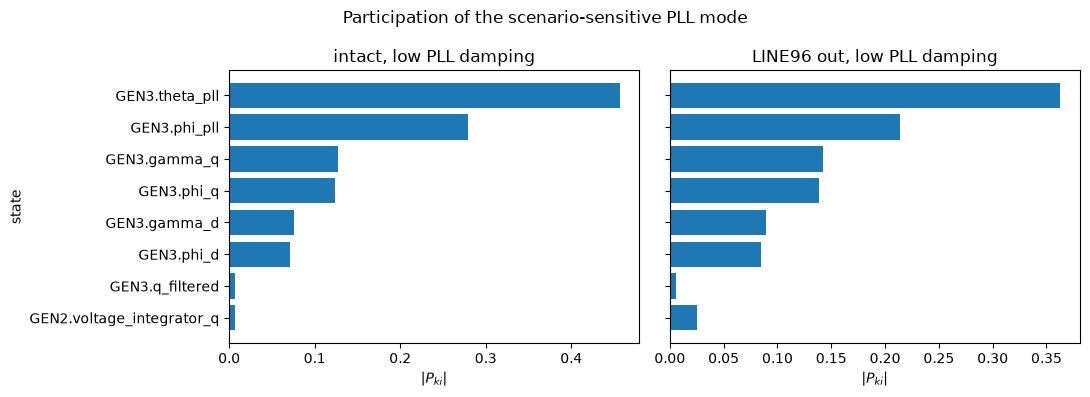

In [19]:
scenario_rows = []
selected = {}
for label in ['intact, low PLL damping', 'LINE96 out, low PLL damping']:
    run = runs[label]
    mode = pll_mode(run, 'pre_event')
    selected[label] = mode
    scenario_rows.append({'case':label, 'damping [1/s]':mode.lambda_real,
                          'frequency [Hz]':mode.frequency_hz, 'stable':mode.lambda_real < 0})
display(pd.DataFrame(scenario_rows).round({'damping [1/s]':4,'frequency [Hz]':4}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, label in zip(axes, selected):
    run = runs[label]; mode = selected[label]
    _, p, _ = modal_data(run, 'pre_event')
    top = p[p['mode'].eq(int(mode['mode']))].nlargest(8, 'p_abs').sort_values('p_abs')
    ax.barh(top.state_name, top.p_abs)
    ax.set_title(label); ax.set_xlabel(r'$|P_{ki}|$')
axes[0].set_ylabel('state')
fig.suptitle('Participation of the scenario-sensitive PLL mode')
fig.tight_layout()


The participation factors identify the crossing pair as a PLL/GFL control interaction: `theta_pll`, `phi_pll`, and the GFL (q)-axis controller states dominate the post-contingency mode. The GFM synchronization pair remains stable and is not the cause of this transition.


,case,source,damping [1/s],frequency [Hz]
0,"intact, low PLL damping",extracted,-2.3675,1.4086
1,"intact, low PLL damping",EMT matrix-pencil fit,-2.3457,1.4195
2,"LINE96 out, low PLL damping",extracted,0.8507,1.1570
3,"LINE96 out, low PLL damping",EMT matrix-pencil fit,0.8581,1.1567


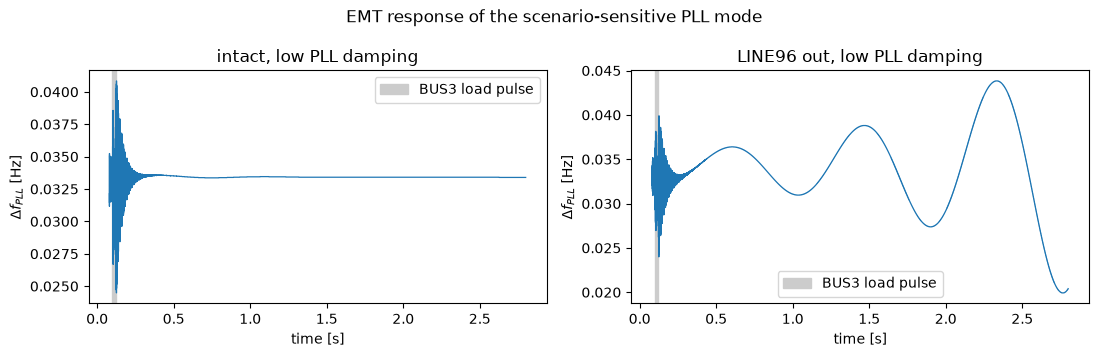

In [20]:
def load_omega(run):
    data = pd.read_csv(log_root/run/f'{run}.csv', skipinitialspace=True)
    data.columns = data.columns.str.strip()
    return data.time.to_numpy(), data['GEN3.omega_pll'].to_numpy()

def matrix_pencil_mode(time, signal, window, expected_frequency, rank=6, stride=100):
    fs = 1/np.median(np.diff(time))
    filtered = sosfiltfilt(butter(6, 5.0, btype='lowpass', fs=fs, output='sos'), signal)
    keep = (time >= window[0]) & (time <= window[1])
    t = time[keep][::stride]; y = filtered[keep][::stride]
    y = y - np.polyval(np.polyfit(t, y, 1), t)
    length = len(y)//2
    h0 = np.column_stack([y[i:i+length] for i in range(len(y)-length)])
    h1 = np.column_stack([y[i+1:i+length+1] for i in range(len(y)-length)])
    u, singular, vh = svd(h0, full_matrices=False)
    reduced = u[:,:rank].T @ h1 @ vh[:rank,:].T @ np.diag(1/singular[:rank])
    poles = np.log(eigvals(reduced))/(t[1]-t[0])
    candidates = poles[poles.imag > 0]
    return candidates[np.argmin(abs(candidates.imag/(2*np.pi)-expected_frequency))]

fit_config = {
    'intact, low PLL damping': ((0.30, 2.50), 1.41),
    'LINE96 out, low PLL damping': ((0.13, 2.80), 1.16),
}
comparison = []
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for ax, label in zip(axes, fit_config):
    run = runs[label]; time, omega = load_omega(run)
    pre = omega[time < 0.09].mean(); deviation_hz = (omega-pre)/(2*np.pi)
    mode = selected[label]; window, expected = fit_config[label]
    fitted = matrix_pencil_mode(time, omega, window, expected)
    comparison.append({'case':label, 'source':'extracted', 'damping [1/s]':mode.lambda_real, 'frequency [Hz]':mode.frequency_hz})
    comparison.append({'case':label, 'source':'EMT matrix-pencil fit', 'damping [1/s]':fitted.real, 'frequency [Hz]':fitted.imag/(2*np.pi)})
    show = (time >= 0.08) & (time <= 2.8)
    ax.plot(time[show], deviation_hz[show], lw=0.9)
    ax.axvspan(0.10, 0.12, color='0.8', label='BUS3 load pulse')
    ax.set_title(label); ax.set_xlabel('time [s]'); ax.set_ylabel(r'$\Delta f_{PLL}$ [Hz]')
    ax.legend()
fig.suptitle('EMT response of the scenario-sensitive PLL mode')
fig.tight_layout()
display(pd.DataFrame(comparison).round({'damping [1/s]':4,'frequency [Hz]':4}))


**Acceptance.** The intact extracted pair is approximately (-2.37\pm j8.85\,\mathrm{s^{-1}}) and the EMT fit is approximately (-2.35\pm j8.92\,\mathrm{s^{-1}}). For the independently initialized `LINE96`-out equilibrium, extraction gives (+0.85\pm j7.27\,\mathrm{s^{-1}}) and the EMT fit gives (+0.85\pm j7.27\,\mathrm{s^{-1}}). Thus the modal analysis predicts the sign of damping, modal frequency, and growth/decay rate on both sides of the topology-driven boundary. This comparison does not claim that the post-contingency equilibrium is reached by the intact-system trajectory.


## Study 3 — timestep-induced split-formulation instability

**Purpose.** Separate a numerical formulation mechanism from the physical PLL mechanism in Study 2. The intact network and controller parameters are held fixed while only the timestep and GFL formulation change. The tracked mode is selected by participation in the GFL capacitor-voltage and filter-current states, rather than by choosing the least-damped eigenvalue.


,formulation,time step [us],damping [1/s],frequency [Hz]
0,variable,10,-39.9891,1727.30
1,variable,25,-39.9487,1726.33
2,variable,50,-39.8016,1722.86
3,variable,75,-39.5661,1717.14
4,variable,100,-39.2523,1709.20
5,split,10,-34.4604,1725.46
6,split,25,-25.9559,1715.49
7,split,50,-12.2477,1681.80
8,split,75,-0.2421,1630.58
9,split,100,9.4630,1567.21


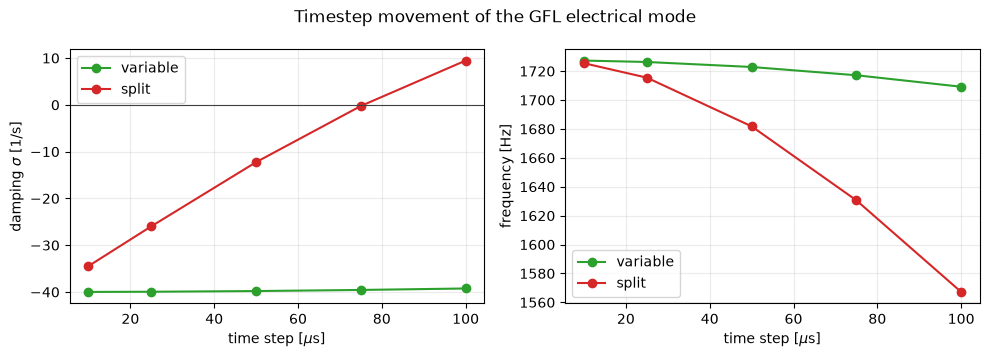

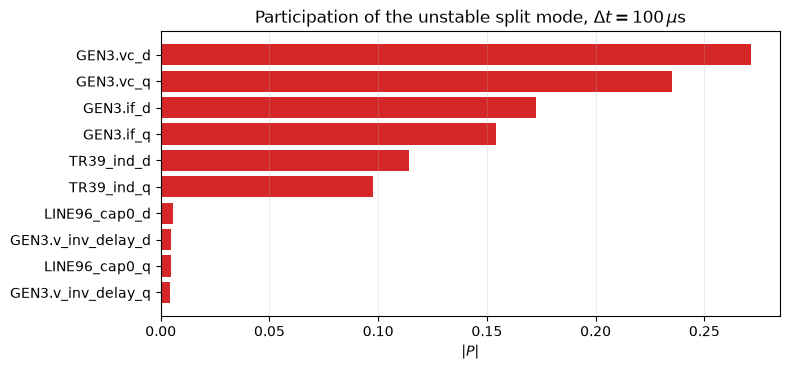

In [21]:
def gfl_electrical_mode(run, label='baseline'):
    modes, participation, _ = modal_data(run, label)
    candidates = modes[np.isfinite(modes.lambda_real) & (modes.lambda_imag > 0)
                       & modes.frequency_hz.between(1000, 2500)].copy()
    electrical = participation[participation.state_name.str.contains(r'GEN3\.(?:vc|if)_[dq]', regex=True)]
    scores = electrical.groupby('mode').p_abs.sum()
    candidates['electrical_score'] = candidates['mode'].map(scores).fillna(0.0)
    return candidates.loc[candidates.electrical_score.idxmax()]

formulation_rows = []
formulation_modes = {}
for formulation in ['variable', 'split']:
    for dt_us in formulation_steps_us:
        run = f'ieee9_form_{formulation}_{dt_us}us'
        mode = gfl_electrical_mode(run)
        formulation_modes[(formulation, dt_us)] = mode
        formulation_rows.append({'formulation': formulation, 'time step [us]': dt_us,
                                 'damping [1/s]': mode.lambda_real,
                                 'frequency [Hz]': mode.frequency_hz})
formulation_table = pd.DataFrame(formulation_rows)
display(formulation_table.round({'damping [1/s]': 4, 'frequency [Hz]': 2}))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for formulation, color in [('variable', 'tab:green'), ('split', 'tab:red')]:
    rows = formulation_table[formulation_table.formulation == formulation]
    axes[0].plot(rows['time step [us]'], rows['damping [1/s]'], 'o-', color=color, label=formulation)
    axes[1].plot(rows['time step [us]'], rows['frequency [Hz]'], 'o-', color=color, label=formulation)
axes[0].axhline(0, color='0.25', lw=0.8); axes[0].set_ylabel(r'damping $\sigma$ [1/s]')
axes[1].set_ylabel('frequency [Hz]')
for ax in axes:
    ax.set_xlabel(r'time step [$\mu$s]'); ax.grid(alpha=0.25); ax.legend()
fig.suptitle('Timestep movement of the GFL electrical mode')
fig.tight_layout()

modes_100, participation_100, _ = modal_data('ieee9_form_split_100us')
critical_100 = formulation_modes[('split', 100)]
top_participation = (participation_100[participation_100['mode'] == int(critical_100['mode'])]
                     .nlargest(10, 'p_abs').sort_values('p_abs'))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(top_participation.state_name, top_participation.p_abs, color='tab:red')
ax.set_xlabel(r'$|P|$'); ax.set_title(r'Participation of the unstable split mode, $\Delta t=100\,\mu$s')
ax.grid(axis='x', alpha=0.25); fig.tight_layout()


The split branch loses damping as the timestep increases and crosses the stability boundary between 75 and 100 microseconds. Its dominant participation is electrical (`GEN3.vc_d/q` and `GEN3.if_d/q`); the PLL angle contribution is small. The variable branch remains stable over the same sweep.

The following EMT free responses start from the power-flow state with the same small 2 ms BUS3 load pulse applied at time zero. They compare the two proposed remedies directly: reduce the split timestep to 50 microseconds, or retain 100 microseconds and use the variable formulation.


,case,extracted damping [1/s],envelope damping [1/s],frequency [Hz]
0,"split, 50 us",-12.248,-12.317,1681.799
1,"split, 100 us",9.463,9.584,1567.214
2,"variable, 100 us",-39.252,NaN,1709.196


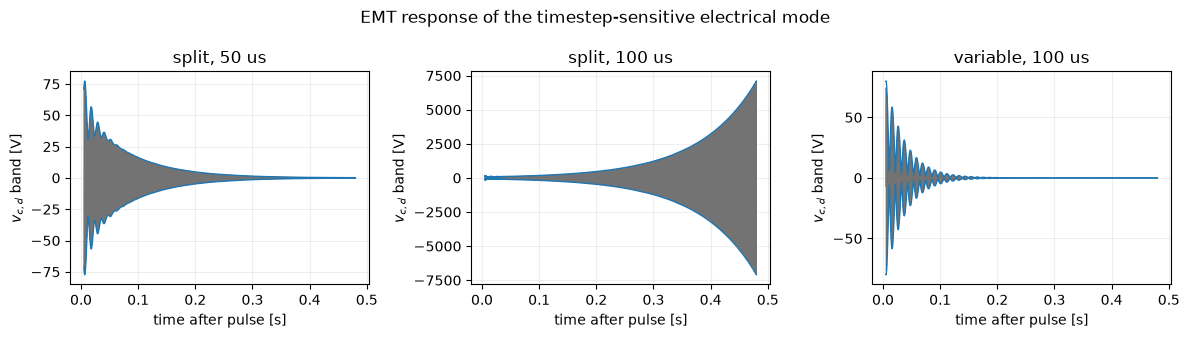

In [22]:
response_cases = {
    'split, 50 us': ('ieee9_form_td_split_50us', (0.03, 0.20), formulation_modes[('split', 50)]),
    'split, 100 us': ('ieee9_form_td_split_100us', (0.03, 0.45), formulation_modes[('split', 100)]),
    'variable, 100 us': ('ieee9_form_td_variable_100us', None, formulation_modes[('variable', 100)]),
}
response_rows = []
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
for ax, (case, (run, fit_window, mode)) in zip(axes, response_cases.items()):
    data = pd.read_csv(log_root/run/f'{run}.csv', skipinitialspace=True)
    data.columns = data.columns.str.strip()
    data = data[data.time > 0].sort_values('time')
    time = data.time.to_numpy(); signal = data['GEN3.vc_d'].to_numpy()
    sampling_frequency = 1/np.median(np.diff(time))
    filtered = sosfiltfilt(butter(4, [1200, 2200], btype='bandpass',
                                  fs=sampling_frequency, output='sos'), signal)
    envelope = np.abs(hilbert(filtered))
    show = (time >= 0.005) & (time <= min(0.48, time.max()-0.002))
    ax.plot(time[show], filtered[show], lw=0.45, color='0.45')
    ax.plot(time[show], envelope[show], lw=1.0, color='tab:blue')
    ax.plot(time[show], -envelope[show], lw=1.0, color='tab:blue')
    ax.set_title(case); ax.set_xlabel('time after pulse [s]'); ax.set_ylabel(r'$v_{c,d}$ band [V]')
    ax.grid(alpha=0.2)
    fitted_damping = np.nan
    if fit_window is not None:
        fit = (time >= fit_window[0]) & (time <= fit_window[1]) & (envelope > 1e-6)
        fitted_damping = np.polyfit(time[fit], np.log(envelope[fit]), 1)[0]
    response_rows.append({'case': case, 'extracted damping [1/s]': mode.lambda_real,
                          'envelope damping [1/s]': fitted_damping,
                          'frequency [Hz]': mode.frequency_hz})
fig.suptitle('EMT response of the timestep-sensitive electrical mode')
fig.tight_layout()
display(pd.DataFrame(response_rows).round(3))


**Acceptance.** At 50 microseconds the split extraction predicts approximately -12.25 inverse seconds and the EMT envelope fit gives approximately -12.32 inverse seconds. At 100 microseconds it predicts approximately +9.46 inverse seconds and the EMT envelope fit gives approximately +9.58 inverse seconds. The variable formulation remains stable at 100 microseconds. This confirms the predicted sign and magnitude of the timestep-induced damping change and demonstrates both recovery actions without conflating this fast electrical mode with the slow PLL instability of Study 2.


## Study 4 — modal update after a settled network event

**Purpose.** Demonstrate the value of extracting a state-space model from the state actually reached by a running simulation. One variable-formulation EMT simulation starts from the intact power-flow initialization, opens `LINE96` at 0.5 s, and then continues without reinitialization. The final modal snapshot is taken at 70 s, after the slow post-event redistribution has settled. Thus, both snapshots belong to the same trajectory; neither an independently initialized outage case nor a frozen-time trajectory is used as the stability indicator.


,signal,last 5 s span [pu],last 5 s slope [pu/s],final-cycle span [pu]
0,GEN2.p_inst,8.750e-05,1.738e-05,5.000e-07
1,GEN2.q_inst,3.630e-05,7.225e-06,1.000e-07
2,GEN3.p_inst,4.000e-07,1.597e-09,2.000e-07
3,GEN3.q_inst,5.000e-07,1.721e-09,3.000e-07
4,GEN2.omega,0.000e+00,7.803e-16,0.000e+00
5,GEN3.omega_pll,2.653e-07,-2.029e-08,2.653e-07


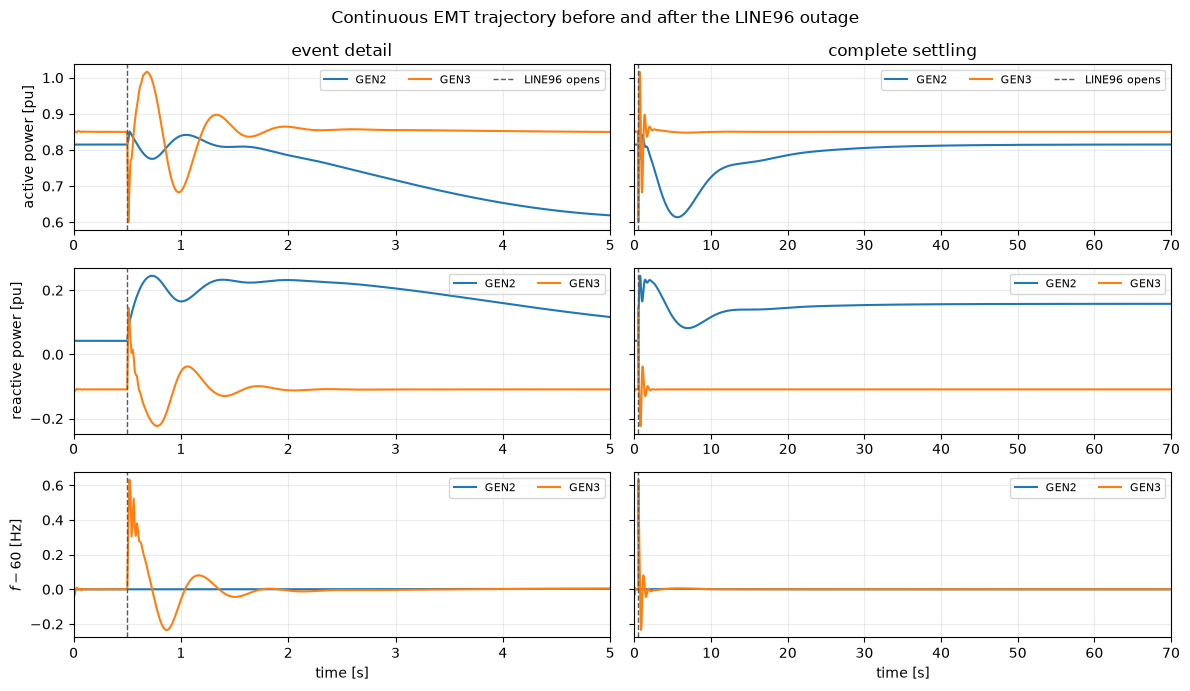

In [23]:
dynamic_run = runs['settled dynamic LINE96 outage']
dynamic = pd.read_csv(log_root/dynamic_run/f'{dynamic_run}.csv', skipinitialspace=True)
dynamic.columns = dynamic.columns.str.strip()
dynamic = dynamic[dynamic.time > 0].sort_values('time')
event_time = 0.5
ratings = {'GEN2.p_inst': 200e6, 'GEN2.q_inst': 200e6,
           'GEN3.p_inst': 100e6, 'GEN3.q_inst': 100e6,
           'GEN2.omega': 2*np.pi*60, 'GEN3.omega_pll': 2*np.pi*60}

show = dynamic.iloc[::200]
fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharey='row')
for column, (view_title, x_limits) in enumerate([('event detail', (0, 5)),
                                                  ('complete settling', (0, 70))]):
    for converter, color in [('GEN2', 'tab:blue'), ('GEN3', 'tab:orange')]:
        axes[0, column].plot(show.time, show[f'{converter}.p_inst']/ratings[f'{converter}.p_inst'],
                             color=color, label=converter)
        axes[1, column].plot(show.time, show[f'{converter}.q_inst']/ratings[f'{converter}.q_inst'],
                             color=color, label=converter)
    axes[2, column].plot(show.time, show['GEN2.omega']/(2*np.pi)-60,
                         label='GEN2', color='tab:blue')
    axes[2, column].plot(show.time, show['GEN3.omega_pll']/(2*np.pi)-60,
                         label='GEN3', color='tab:orange')
    for row in range(3):
        axes[row, column].axvline(event_time, color='0.35', ls='--', lw=1,
                                 label='LINE96 opens' if row == 0 else None)
        axes[row, column].set_xlim(*x_limits); axes[row, column].grid(alpha=0.25)
        axes[row, column].legend(ncol=3, fontsize=8)
    axes[0, column].set_title(view_title)
    axes[2, column].set_xlabel('time [s]')
axes[0, 0].set_ylabel('active power [pu]')
axes[1, 0].set_ylabel('reactive power [pu]')
axes[2, 0].set_ylabel(r'$f-60$ [Hz]')
fig.suptitle('Continuous EMT trajectory before and after the LINE96 outage')
fig.tight_layout()

settling_rows = []
last_five = dynamic[dynamic.time >= dynamic.time.max()-5]
final_cycle = dynamic[dynamic.time >= dynamic.time.max()-1/60]
for signal, base in ratings.items():
    t = last_five.time.to_numpy(); y = last_five[signal].to_numpy()/base
    settling_rows.append({'signal': signal,
                          'last 5 s span [pu]': np.ptp(y),
                          'last 5 s slope [pu/s]': np.polyfit(t-t.mean(), y, 1)[0],
                          'final-cycle span [pu]': np.ptp(final_cycle[signal].to_numpy()/base)})
settling = pd.DataFrame(settling_rows)
settling_display = settling.copy()
for column in settling.columns[1:]:
    settling_display[column] = settling_display[column].map(lambda value: f'{value:.3e}')
display(settling_display)


The long settling interval is deliberate. The post-event model contains a slow real mode near -0.11 inverse seconds, so a short run can look visually quiet while the operating point is still drifting. The table quantifies both slow drift over the final five seconds and periodic ripple over the final fundamental cycle before the modal result is interpreted.


,snapshot,damping [1/s],frequency [Hz],damping ratio,stable
0,"intact, immediately before outage",-10.0620,1.1840,0.8041,True
1,"LINE96 out, settled",-1.6157,1.4727,0.1720,True


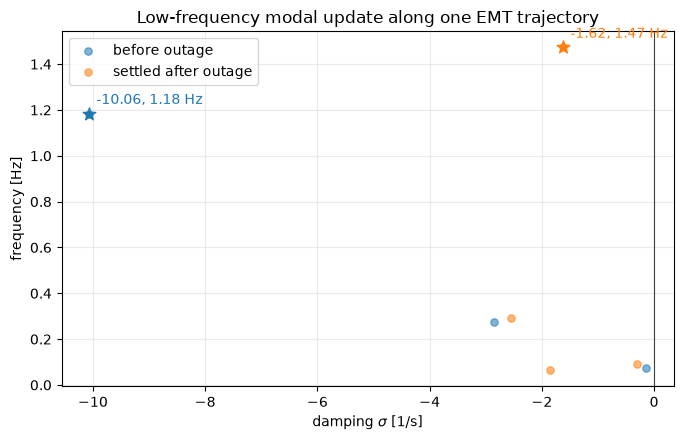

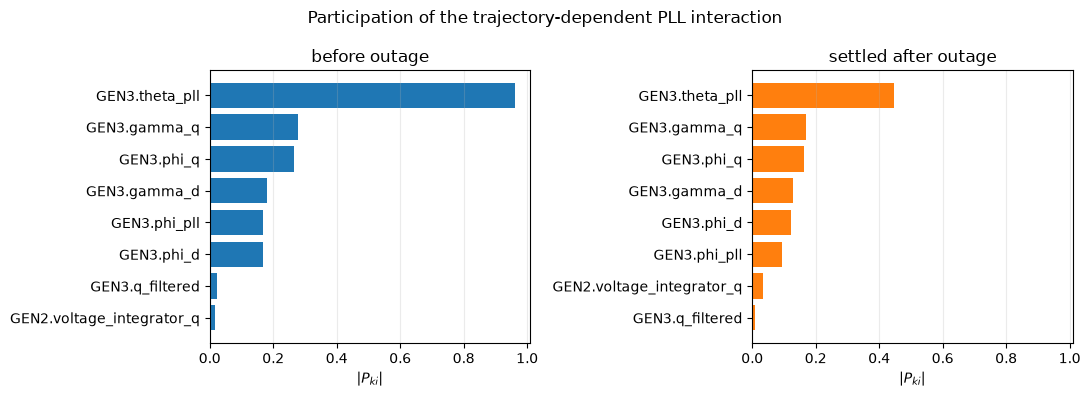

In [24]:
dynamic_modes = {}
modal_rows = []
for snapshot, description in [('pre_event', 'intact, immediately before outage'),
                              ('post_event', 'LINE96 out, settled')]:
    mode = pll_mode(dynamic_run, snapshot)
    dynamic_modes[snapshot] = mode
    omega_abs = np.hypot(mode.lambda_real, mode.lambda_imag)
    modal_rows.append({'snapshot': description, 'damping [1/s]': mode.lambda_real,
                       'frequency [Hz]': mode.frequency_hz,
                       'damping ratio': -mode.lambda_real/omega_abs,
                       'stable': mode.lambda_real < 0})
display(pd.DataFrame(modal_rows).round({'damping [1/s]':4, 'frequency [Hz]':4,
                                        'damping ratio':4}))

fig, ax = plt.subplots(figsize=(7, 4.5))
for snapshot, description, color in [('pre_event', 'before outage', 'tab:blue'),
                                      ('post_event', 'settled after outage', 'tab:orange')]:
    modes, _, _ = modal_data(dynamic_run, snapshot)
    visible = modes[np.isfinite(modes.lambda_real) & modes.frequency_hz.between(0.05, 10)
                    & modes.lambda_real.between(-30, 5) & (modes.lambda_imag > 0)]
    ax.scatter(visible.lambda_real, visible.frequency_hz, s=28, alpha=0.55,
               color=color, label=description)
    mode = dynamic_modes[snapshot]
    ax.scatter(mode.lambda_real, mode.frequency_hz, s=90, marker='*', color=color)
    ax.annotate(f'{mode.lambda_real:.2f}, {mode.frequency_hz:.2f} Hz',
                (mode.lambda_real, mode.frequency_hz), xytext=(5, 7),
                textcoords='offset points', color=color)
ax.axvline(0, color='0.25', lw=0.8); ax.grid(alpha=0.25)
ax.set_xlabel(r'damping $\sigma$ [1/s]'); ax.set_ylabel('frequency [Hz]')
ax.set_title('Low-frequency modal update along one EMT trajectory'); ax.legend()
fig.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, snapshot, description in zip(axes, ['pre_event', 'post_event'],
                                      ['before outage', 'settled after outage']):
    _, participation, _ = modal_data(dynamic_run, snapshot)
    mode = dynamic_modes[snapshot]
    top = participation[participation['mode'].eq(int(mode['mode']))].nlargest(8, 'p_abs').sort_values('p_abs')
    ax.barh(top.state_name, top.p_abs, color='tab:blue' if snapshot == 'pre_event' else 'tab:orange')
    ax.set_title(description); ax.set_xlabel(r'$|P_{ki}|$'); ax.grid(axis='x', alpha=0.25)
fig.suptitle('Participation of the trajectory-dependent PLL interaction')
fig.tight_layout()


**Acceptance.** Over the final five seconds, every monitored state has a span below (9\times10^{-5}) pu and an absolute fitted slope below (2\times10^{-5}) pu/s; final-cycle ripple remains below (10^{-6}) pu. The PLL-dominated pair moves from approximately (-10.06\pm j7.44\,\mathrm{s^{-1}}) at 1.184 Hz before the outage to (-1.62\pm j9.25\,\mathrm{s^{-1}}) at 1.473 Hz after settlement. Its participation remains dominated by GFL PLL and current-control states, while the increased GFM voltage-integrator contribution is consistent with stronger converter interaction after the network is weakened. The post-event pair remains in the left half-plane and the same EMT trajectory settles. This validates the modal update at two genuine steady operating points reached by one simulation; it does not infer stability from a transient frozen-time snapshot.
